## Goal of this

- create a 2x2 budget with the time snaps in the miniASTE
- create a Barents Sea budget with the snaps and explain the difference between the ADVh term and the M gates

In [1]:
# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")

# run the script into the curre nt kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/prep_grid_aste_90.py"

(450, 90)
RAC2d (40500,)
(100,)


In [2]:
# we need to load the miniaste
dirroot = "/scratch3/atnguyen/aste_90x150x60/"
dirgrid = dirroot + "GRID_real8/"
dirgridnb = dirroot + "GRID_noblank/"
runstr= "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"
layers_path = dirroot + runstr
extL = "LAYERS"
dirmask = dirroot + "run_template/input_maskTransport/"
dirbudg = layers_path + "diags/BUDG/"
dirdiags = dirbudg
dirstate = layers_path + "diags/STATE/"
dirlayers = layers_path + "diags/LAYERS/"
dirtrsp = layers_path + "diags/TRSP/"

In [3]:
# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)

ind2d = ind.reshape(ny,nx)

mymsk = np.full((ny,nx),np.nan)
mymsk[ind2d == 57408.0] = 1

# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

ind = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind == 57408.0] = 1

# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

In [4]:
# load the ADV terms for the Barents Sea for this singular box -- single box will all be contributing the same
# to the same T or S bin, so these will be the same when plotted in T or S space
# but we can show this anyways
tsstr = np.array(["0000000002","0000000003"])
t2 = int(tsstr[1]) # for the offline version

In [5]:
# load the TS bins
# also load the bins again so we have them locally
boundsT = np.round(np.squeeze(rdmds(layers_path + "layers2TH")).ravel(),1)
nT = boundsT.size - 1
boundsS = np.round(np.squeeze(rdmds(layers_path + "layers1SLT")).ravel(),1)
nS = boundsS.size - 1
binwidthT = boundsT[1:] - boundsT[:-1]
binwidthS = boundsS[1:] - boundsS[:-1]
binwidthT1 = 0.5 * (binwidthT[1:] + binwidthT[:-1])  # normalize by these
binwidthS1 = 0.5 * (binwidthS[1:] + binwidthS[:-1])
binmidT = (boundsT[1:] + boundsT[:-1]) /2    # bin to these
binmidS = (boundsS[1:] + boundsS[:-1]) /2
nT = nT
nS = nS
nTm1 = nT-1
nSm1 = nS-1

## Load the diagnostics and have them in the correct shape in general

In [6]:
t2 = int(tsstr[1])
# 'diags/state_3d_set1'
# read theta and salt averages from the t2 timestep (average)
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz,ny,nx)
SALT = SALT.reshape(nz,ny,nx)

In [10]:
# using the function we did before, create the dfT_new
# then we can create the gates below

from create_aste90_layers import create_layers_totalTHETA,create_layers_totalSALT  # ,create_layers_totalSALT
# we will need to modify this to bin at face theta and return more than just the Msum
dt = 1800

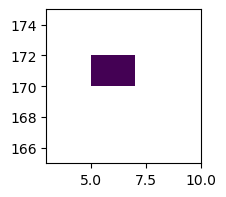

In [11]:
# define some random mask or 2x2
mymsk = np.full((ny,nx),np.nan)
mymsk[170,5] = 1
mymsk[171,5] = 1
mymsk[170,6] = 1
mymsk[171,6] = 1

fig = plt.figure(figsize=(2,2))
plt.pcolormesh(mymsk)
plt.xlim(3,10)
plt.ylim(165,175)

# define the four gates here
xw,yw = np.array([5,5]),np.array([170,171])  # read +ADVx at avg of x-1 theta
xe,ye = np.array([7,7]),np.array([170,171])  # read -ADVx at avg of x+1 theta
xs,ys = np.array([5,6]),np.array([170,170])  # read +ADVy at avg of y-1 theta
xn,yn = np.array([5,6]),np.array([172,172])  # read -ADVy at avg of y+1 theta

In [12]:
_, dF_Tnew = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt)
_, dF_Snew = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt)


In [14]:
# create the gates manually using the indices

file_name = "budg3d_hflux_set2"
meta_budg3d_hflux_set2 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg3d_hflux_set2["fldList"])
varnames = np.array(["ADVx_TH","ADVy_TH"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
ADVx_TH,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[0])
ADVy_TH,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[1])
ADVx_TH = ADVx_TH.reshape((nz,ny,nx))
ADVy_TH = ADVy_TH.reshape((nz,ny,nx))

In [16]:
# this is on one face, so we can take a diff in x and y and average for the temperature
def bin_gate_by_face_theta_zero(theta_s, flux_s, binmidT, nTm1):
    theta_s = np.asarray(theta_s)
    flux_s  = np.asarray(flux_s)

    # edges from midpoints
    edges = centers_to_edges(binmidT)

    out = np.zeros(nTm1, dtype=float)
    good = np.isfinite(theta_s) & np.isfinite(flux_s)
    theta_s = theta_s[good]
    flux_s  = flux_s[good]

    ib = np.digitize(theta_s, edges) - 1
    ok = (ib >= 0) & (ib < nTm1)
    np.add.at(out, ib[ok], flux_s[ok])
    return out


def bin_2x2_gates_by_face_theta(
    THETA, ADVx_TH, ADVy_TH,
    *,
    nz, ny, nx,
    binmidT, nTm1,
    binwidthT1=None,   # optional: if you want normalized G's too
    # gate point arrays (as you defined)
    xw=None, yw=None,
    xe=None, ye=None,
    xs=None, ys=None,
    xn=None, yn=None,
    eps=1e-6,
    divide_by_theta=False,  # set True if you really want q_vol = q_heat/theta
):
    # --- reshape to 3D ---
    ADVx_TH = np.asarray(ADVx_TH).reshape((nz, ny, nx))
    ADVy_TH = np.asarray(ADVy_TH).reshape((nz, ny, nx))
    THETA   = np.asarray(THETA).reshape((nz, ny, nx))

    # ------------------------------------------------------------------
    # 1) Build theta at faces
    # ------------------------------------------------------------------
    theta_x = np.zeros_like(ADVx_TH, dtype=float)
    theta_x[:, :, 1:] = 0.5 * (THETA[:, :, 1:] + THETA[:, :, :-1])
    theta_x[:, :, 0]  = theta_x[:, :, 1]  # west boundary fill

    theta_y = np.zeros_like(ADVy_TH, dtype=float)
    theta_y[:, 1:, :] = 0.5 * (THETA[:, 1:, :] + THETA[:, :-1, :])
    theta_y[:, 0, :]  = theta_y[:, 1, :]  # south boundary fill

    # ------------------------------------------------------------------
    # 2) Convert heat flux -> "volume" flux (optional divide)
    # ------------------------------------------------------------------
    ADVx_vol = np.zeros_like(ADVx_TH, dtype=float)
    mask_x = np.isfinite(theta_x) & (np.abs(theta_x) > eps) & np.isfinite(ADVx_TH)
    if divide_by_theta:
        ADVx_vol[mask_x] = ADVx_TH[mask_x] / theta_x[mask_x]
    else:
        ADVx_vol[mask_x] = ADVx_TH[mask_x]

    ADVy_vol = np.zeros_like(ADVy_TH, dtype=float)
    mask_y = np.isfinite(theta_y) & (np.abs(theta_y) > eps) & np.isfinite(ADVy_TH)
    if divide_by_theta:
        ADVy_vol[mask_y] = ADVy_TH[mask_y] / theta_y[mask_y]
    else:
        ADVy_vol[mask_y] = ADVy_TH[mask_y]

    # ------------------------------------------------------------------
    # 3) Helper: collect samples from a set of (j,i) face points and bin
    # ------------------------------------------------------------------
    def collect_and_bin(face_theta, face_flux, ys, xs, sign=+1.0):
        if ys is None or xs is None:
            return np.zeros(nTm1, dtype=float)

        ys = np.asarray(ys, dtype=int)
        xs = np.asarray(xs, dtype=int)
        if ys.size == 0:
            return np.zeros(nTm1, dtype=float)

        t_list, f_list = [], []
        for j, i in zip(ys, xs):
            t_list.append(face_theta[:, j, i].ravel())
            f_list.append((sign * face_flux[:, j, i]).ravel())

        theta_s = np.concatenate(t_list) if t_list else np.array([], dtype=float)
        flux_s  = np.concatenate(f_list) if f_list else np.array([], dtype=float)

        return bin_gate_by_face_theta_zero(theta_s, flux_s, binmidT, nTm1)

    # ------------------------------------------------------------------
    # 4) Bin only your 2×2 box gates
    #    Following your sign comments:
    #      W: +ADVx
    #      E: -ADVx
    #      S: +ADVy
    #      N: -ADVy
    # ------------------------------------------------------------------
    ADVh_W = collect_and_bin(theta_x, ADVx_vol, yw, xw, sign=+1.0)
    ADVh_E = collect_and_bin(theta_x, ADVx_vol, ye, xe, sign=-1.0)
    ADVh_S = collect_and_bin(theta_y, ADVy_vol, ys, xs, sign=+1.0)
    ADVh_N = collect_and_bin(theta_y, ADVy_vol, yn, xn, sign=-1.0)

    Msum = {
        "W": ADVh_W,
        "E": ADVh_E,
        "S": ADVh_S,
        "N": ADVh_N,
        "Msum": ADVh_W + ADVh_E + ADVh_S + ADVh_N,
    }

    # Optional normalized versions (if you want to plot like before)
    if binwidthT1 is not None:
        Msum_norm = {k: (v / binwidthT1) for k, v in Msum.items()}
        return Msum, Msum_norm

    return Msum

# your 2x2 gate points
xw,yw = np.array([5,5]), np.array([170,171])
xe,ye = np.array([7,7]), np.array([170,171])
xs,ys = np.array([5,6]), np.array([170,170])
xn,yn = np.array([5,6]), np.array([172,172])

Msum = bin_2x2_gates_by_face_theta(
    THETA, ADVx_TH, ADVy_TH,
    nz=nz, ny=ny, nx=nx,
    binmidT=binmidT, nTm1=nTm1,
    xw=xw, yw=yw, xe=xe, ye=ye, xs=xs, ys=ys, xn=xn, yn=yn,
    divide_by_theta=False,   # matches your snippet (division commented out)
)


NameError: name 'centers_to_edges' is not defined

## First import the packages and do the 2x2 with closure, show the difference.

We can look at some sample version from the sample_2_3 notebook for binning at the face theta and face salt.

In [9]:
# create the gateway M term from these indices
# we can do the same as before where we make 3D then go back to nTm1
M_W = 

SyntaxError: invalid syntax (771476588.py, line 3)

## Load the proved-closed gates and recreate the same figure from the 1/20 meeting

This is in verify_gates_aste90.ipynb but without the separation of gates individually.

Recall here from the previous notebook we binned at cell center, we want to bin at faces.